In [1]:
!pip install numpy
!pip install pandas
!pip install pickle
!pip install pyarrow
!pip install seaborn
!pip install scikit-learn

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [2]:
!pip install --upgrade scikit-learn

In [3]:
import numpy as np
import pandas as pd
import pickle
import joblib


from matplotlib import pyplot as plt
import seaborn as sns

import os

In [4]:
os.listdir()

['.ipynb_checkpoints',
 'IB data samples.ipynb',
 'M1_logistica.pkl',
 'M2_random_forest.pkl',
 'M3_gbm_completo.pkl',
 'M4_gbm_moderado.pkl',
 'M5_naive_bayes.pkl',
 'metricas_T0_validacion.json',
 'metricas_temporales.csv',
 'operaciones.parquet',
 'operaciones_T0_train.parquet',
 'operaciones_T0_valid.parquet',
 'operaciones_T1.parquet',
 'operaciones_T1_etiquetadas.parquet']

In [5]:
df_metrics = pd.read_csv('metricas_temporales.csv')
print(df_metrics.shape)
df_metrics.head()

(120, 12)


,modelo,mes,fase,n,n_fraude,f1,f1_med,f1_lo,f1_hi,precision,recall,auc_pr
0,M1_logistica,1,T0,51439,435,0.234848,0.231206,0.197288,0.272964,0.260504,0.213793,0.177202
1,M1_logistica,2,T0,48092,427,0.223881,0.223708,0.183145,0.259829,0.238727,0.210773,0.179768
2,M1_logistica,3,T0,50875,394,0.197889,0.198593,0.159882,0.237472,0.206044,0.190355,0.144582
3,M1_logistica,4,T0,51456,402,0.229219,0.226226,0.190837,0.269420,0.232143,0.226368,0.168400
4,M1_logistica,5,T0,52497,420,0.264741,0.265336,0.226278,0.307556,0.267640,0.261905,0.188016


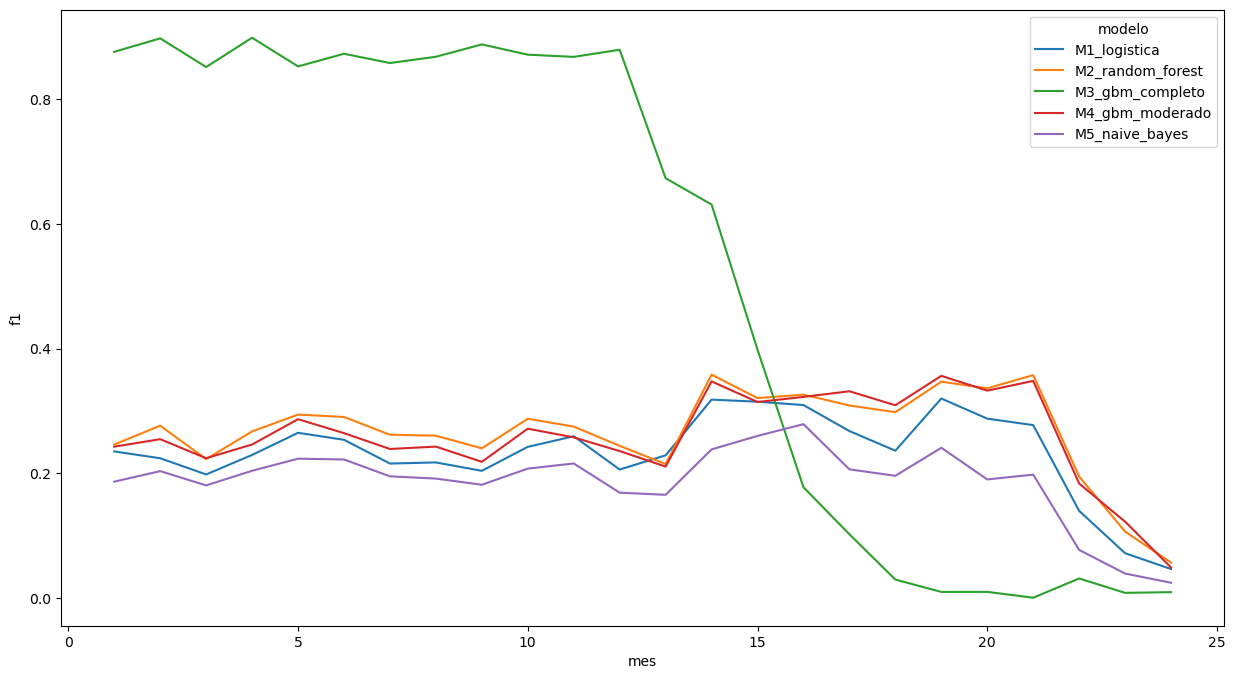

In [6]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_metrics,x='mes', y='f1', hue='modelo')
plt.show()

# DF structure

In [7]:
df_ops = pd.read_parquet('operaciones.parquet')
print(df_ops.shape)
df_ops.head()

(1202670, 10)


,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,1,1,atm,noche,conocido,10.302010,0.065214,3,True,False
1,2,1,online,tarde,conocido,8.740580,0.181161,2,True,False
2,3,1,online,tarde,conocido,7.807675,0.361172,3,True,False
3,4,1,online,manana,registrado_reciente,7.084236,0.086316,2,True,False
4,5,1,online,tarde,registrado_reciente,9.144403,0.384047,2,True,False


In [8]:
df_ops_t0 = pd.read_parquet('operaciones_T0_train.parquet')
print(df_ops_t0.shape)
df_ops_t0.head()

(420460, 10)


,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,1,1,atm,noche,conocido,10.302010,0.065214,3,True,False
1,2,1,online,tarde,conocido,8.740580,0.181161,2,True,False
2,3,1,online,tarde,conocido,7.807675,0.361172,3,True,False
3,4,1,online,manana,registrado_reciente,7.084236,0.086316,2,True,False
4,5,1,online,tarde,registrado_reciente,9.144403,0.384047,2,True,False


In [9]:
df_ops_t1 = pd.read_parquet('operaciones_T1.parquet')
print(df_ops_t1.shape)
df_ops_t1.head()

(601378, 10)


,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,601293,13,presencial,noche,conocido,7.957897,0.038116,3,False,False
1,601294,13,presencial,noche,registrado_reciente,7.811474,0.197759,4,False,False
2,601295,13,presencial,tarde,conocido,9.346672,0.114964,4,False,False
3,601296,13,presencial,tarde,registrado_reciente,9.739413,0.316095,1,True,False
4,601297,13,online,manana,conocido,8.348123,0.076566,2,True,False


In [10]:
df_ops_t1_et = pd.read_parquet('operaciones_T1_etiquetadas.parquet')
print(df_ops_t1_et.shape)
df_ops_t1_et.head()

(180365, 10)


,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,601296,13,presencial,tarde,registrado_reciente,9.739413,0.316095,1,True,False
1,601297,13,online,manana,conocido,8.348123,0.076566,2,True,False
2,601298,13,atm,tarde,conocido,7.679568,0.035412,2,True,False
3,601299,13,presencial,manana,conocido,8.165072,0.053509,2,True,False
4,601304,13,presencial,noche,registrado_reciente,10.537983,0.222534,2,True,False


# Metrics

In [11]:
import json

In [12]:
# Load JSON
with open("metricas_T0_validacion.json", "r", encoding="utf-8") as f:
    metricas = json.load(f)

In [13]:
validation_df = pd.read_json("metricas_T0_validacion.json")
validation_df = validation_df.T.reset_index().rename(columns={"index": "modelo"})
train_df = pd.json_normalize(validation_df["T0_train"]).add_prefix("train_")
valid_df = pd.json_normalize(validation_df["T0_validacion"]).add_prefix("valid_")
df_final = pd.concat(
    [
        validation_df.drop(columns=["T0_train", "T0_validacion"]),
        train_df,
        valid_df
    ],
    axis=1
)

df_final.head()

,modelo,descripcion,features,threshold,train_n,train_n_fraude,train_threshold,train_TP,train_FP,train_FN,...,valid_TP,valid_FP,valid_FN,valid_TN,valid_precision,valid_recall,valid_f1,valid_accuracy,valid_auc_roc,valid_auc_pr
0,M1_logistica,Regresión logística lineal con 3 features (mon...,"[monto_log, canal, dispositivo]",0.14,420460,3355,0.14,715,2305,2640,...,347,1065,1101,178319,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716
1,M2_random_forest,Random Forest con 5 features (incluye hora_bin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,420460,3355,0.11,945,2604,2410,...,377,1272,1071,178112,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155
2,M3_gbm_completo,Gradient Boosting completo con 6 features incl...,"[monto_log, secuencia_24h, terminal_risk_score...",0.46,420460,3355,0.46,2896,273,459,...,1176,170,272,179214,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691
3,M4_gbm_moderado,Gradient Boosting moderado con 5 features (sin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,420460,3355,0.11,963,3228,2392,...,395,1507,1053,177877,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068
4,M5_naive_bayes,Naive Bayes Gaussiano con solo 2 features estr...,"[monto_log, secuencia_24h]",0.11,420460,3355,0.11,675,2998,2680,...,330,1312,1118,178072,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176


In [14]:
df_final["valid_f1_manual"] = (2 * df_final["valid_TP"] / (2 * df_final["valid_TP"] + df_final["valid_FP"] + df_final["valid_FN"]))
df_final[["modelo","valid_f1","valid_f1_manual"]]

,modelo,valid_f1,valid_f1_manual
0,M1_logistica,0.242657,0.242657
1,M2_random_forest,0.243461,0.243461
2,M3_gbm_completo,0.841804,0.841804
3,M4_gbm_moderado,0.235821,0.235821
4,M5_naive_bayes,0.213592,0.213592


# Loading models

In [15]:
from sklearn.linear_model import LogisticRegression

### M1

In [16]:
with open("M1_logistica.pkl", "rb") as f:
    model_logistic = loaded_pipeline = joblib.load(f)

In [17]:
df_train_t0 = pd.read_parquet('operaciones_T0_train.parquet')
df_train_t0.head()

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,1,1,atm,noche,conocido,10.302010,0.065214,3,True,False
1,2,1,online,tarde,conocido,8.740580,0.181161,2,True,False
2,3,1,online,tarde,conocido,7.807675,0.361172,3,True,False
3,4,1,online,manana,registrado_reciente,7.084236,0.086316,2,True,False
4,5,1,online,tarde,registrado_reciente,9.144403,0.384047,2,True,False


In [19]:
model_logistic

{'pipeline': Pipeline(steps=[('pre',
                  ColumnTransformer(transformers=[('num', 'passthrough',
                                                   ['monto_log']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['canal', 'dispositivo'])])),
                 ('clf',
                  LogisticRegression(max_iter=1000, random_state=20260424))]),
 'features': ['monto_log', 'canal', 'dispositivo'],
 'threshold': 0.14}

In [23]:
# pipeline
pipeline = model_logistic["pipeline"]

# classifier
clf = pipeline.named_steps["clf"]

# preprocessor
preprocessor = pipeline.named_steps["pre"]

# feature names after OneHotEncoder
feature_names = preprocessor.get_feature_names_out()

# coefs
coefficients = clf.coef_[0]

# dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": abs(coefficients)
})

# sort
feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

print(feature_importance)

                                feature  coefficient  abs_coefficient
5             cat__dispositivo_conocido    -5.147800         5.147800
7  cat__dispositivo_registrado_reciente    -4.100411         4.100411
2                     cat__canal_online    -3.745155         3.745155
6          cat__dispositivo_desconocido    -3.643925         3.643925
4              cat__canal_transferencia    -3.191966         3.191966
1                        cat__canal_atm    -3.118152         3.118152
3                 cat__canal_presencial    -2.836863         2.836863
0                        num__monto_log     1.715506         1.715506


In [ ]:
### M3

In [24]:
with open("M3_gbm_completo.pkl", "rb") as f:
    model_logistic = loaded_pipeline = joblib.load(f)

In [25]:
df_val_t0 = pd.read_parquet('operaciones_T0_valid.parquet')
df_val_t0.head()

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude
0,6,1,presencial,manana,conocido,9.077847,0.109766,3,True,False
1,9,1,presencial,manana,conocido,7.037522,0.272513,3,True,False
2,17,1,online,manana,registrado_reciente,9.169156,0.196095,2,True,False
3,22,1,online,tarde,conocido,7.756148,0.072535,4,True,False
4,24,1,transferencia,noche,conocido,7.647944,0.346141,4,True,False


In [29]:
df_val_t0["m3_predictions"] = model_logistic["pipeline"].predict(df_val_t0)

In [31]:
df_val_t0.head()

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude,m3_predictions
0,6,1,presencial,manana,conocido,9.077847,0.109766,3,True,False,False
1,9,1,presencial,manana,conocido,7.037522,0.272513,3,True,False,False
2,17,1,online,manana,registrado_reciente,9.169156,0.196095,2,True,False,False
3,22,1,online,tarde,conocido,7.756148,0.072535,4,True,False,False
4,24,1,transferencia,noche,conocido,7.647944,0.346141,4,True,False,False


In [33]:
df_val_t0.to_csv('operaciones_T0_valid_m3_predictions.csv')

# P4 all models

In [36]:
models = ['M1_logistica.pkl', 'M2_random_forest.pkl', 'M3_gbm_completo.pkl', 'M4_gbm_moderado.pkl', 'M5_naive_bayes.pkl']

In [37]:
df_val_t0_all_models = pd.read_parquet('operaciones_T0_valid.parquet')

In [43]:
for model in models:
    m_name = model.split('_')[0]
    with open(model, "rb") as f:
        # model
        model = loaded_pipeline = joblib.load(f)
        # predictions
        df_val_t0_all_models[f"{m_name}_predictions"] = model["pipeline"].predict(df_val_t0_all_models)

# save predictions
df_val_t0_all_models.to_csv('operaciones_T0_valid_all_predictions.csv')

In [42]:
df_val_t0_all_models.head()

,op_id,mes,canal,hora_bin,dispositivo,monto_log,terminal_risk_score,secuencia_24h,etiquetado,es_fraude,M1_predictions,M2_predictions,M3_predictions,M4_predictions,M5_predictions
0,6,1,presencial,manana,conocido,9.077847,0.109766,3,True,False,False,False,False,False,False
1,9,1,presencial,manana,conocido,7.037522,0.272513,3,True,False,False,False,False,False,False
2,17,1,online,manana,registrado_reciente,9.169156,0.196095,2,True,False,False,False,False,False,False
3,22,1,online,tarde,conocido,7.756148,0.072535,4,True,False,False,False,False,False,False
4,24,1,transferencia,noche,conocido,7.647944,0.346141,4,True,False,False,False,False,False,False
